# 1. Importing Libraries

In [2]:
import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt
import seaborn as sns
import scipy

In [4]:
path = r'C:\Users\bhava\Documents\18.02.26_Instacart Basket Analysis'

# Importing Data

In [5]:
ords_prods_merge_custs = pd.read_pickle(os.path.join(path, '02 Data', 'Prepared Data', 'ords_prods_merge_custs.pkl'))

In [6]:
ords_prods_merge_custs.head()

,order_id,user_id,order_number,order_day_of_week,order_hour_of_day,days_since_last_order,product_id,add_to_cart_order,reordered,product_name,...,ord_regularity_median,frequency_flag,gender,state,age,date_joined,number_of_dependants,marital_status,income,_merge
0,2539329,1,1,2,8,NaN,196,1,0,Soda,...,20.5,Non-frequent customer,Female,Alabama,31,2/17/2019,3,married,40423,both
1,2539329,1,1,2,8,NaN,14084,2,0,Organic Unsweetened Vanilla Almond Milk,...,20.5,Non-frequent customer,Female,Alabama,31,2/17/2019,3,married,40423,both
2,2539329,1,1,2,8,NaN,12427,3,0,Original Beef Jerky,...,20.5,Non-frequent customer,Female,Alabama,31,2/17/2019,3,married,40423,both
3,2539329,1,1,2,8,NaN,26088,4,0,Aged White Cheddar Popcorn,...,20.5,Non-frequent customer,Female,Alabama,31,2/17/2019,3,married,40423,both
4,2539329,1,1,2,8,NaN,26405,5,0,XL Pick-A-Size Paper Towel Rolls,...,20.5,Non-frequent customer,Female,Alabama,31,2/17/2019,3,married,40423,both


In [7]:
ords_prods_merge_custs.tail()

,order_id,user_id,order_number,order_day_of_week,order_hour_of_day,days_since_last_order,product_id,add_to_cart_order,reordered,product_name,...,ord_regularity_median,frequency_flag,gender,state,age,date_joined,number_of_dependants,marital_status,income,_merge
32404854,2977660,206209,13,1,12,7.0,14197,5,1,Tomato Paste,...,22.0,Non-frequent customer,Female,Iowa,74,9/14/2019,3,married,137969,both
32404855,2977660,206209,13,1,12,7.0,38730,6,0,Brownie Crunch High Protein Bar,...,22.0,Non-frequent customer,Female,Iowa,74,9/14/2019,3,married,137969,both
32404856,2977660,206209,13,1,12,7.0,31477,7,0,High Protein Bar Chunky Peanut Butter,...,22.0,Non-frequent customer,Female,Iowa,74,9/14/2019,3,married,137969,both
32404857,2977660,206209,13,1,12,7.0,6567,8,0,Chocolate Peanut Butter Protein Bar,...,22.0,Non-frequent customer,Female,Iowa,74,9/14/2019,3,married,137969,both
32404858,2977660,206209,13,1,12,7.0,22920,9,0,Roasted & Salted Shelled Pistachios,...,22.0,Non-frequent customer,Female,Iowa,74,9/14/2019,3,married,137969,both


In [8]:
ords_prods_merge_custs.shape

(32404859, 31)

In [11]:
ords_prods_merge_custs.columns

Index(['order_id', 'user_id', 'order_number', 'order_day_of_week',
       'order_hour_of_day', 'days_since_last_order', 'product_id',
       'add_to_cart_order', 'reordered', 'product_name', 'aisle_id',
       'department_id', 'prices', 'price_range_loc', 'busiest_day',
       'busiest_days', 'busiest_period_of_day', 'max_order', 'loyalty_flag',
       'avg_spend_user', 'spending_flag', 'ord_regularity_median',
       'frequency_flag', 'gender', 'state', 'age', 'date_joined',
       'number_of_dependants', 'marital_status', 'income', '_merge'],
      dtype='object')

# 3. Histogram

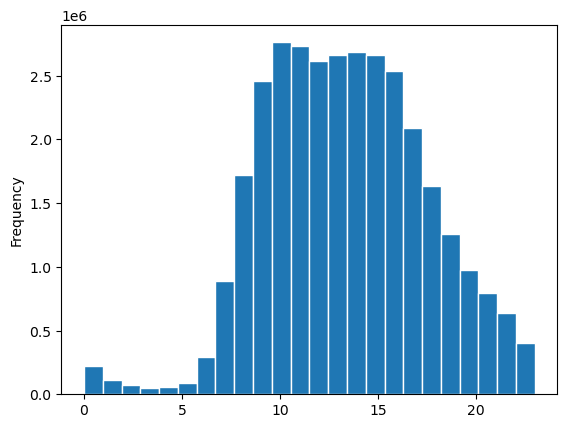

In [18]:
hist = ords_prods_merge_custs['order_hour_of_day'].plot.hist(bins = 24, edgecolor='white')

### Inisghts: The frenquency of orders begins to rise around 06:00 AM in the morning and begins to drop around 17:00 PM. The peak hits around 10:00 AM and stay high until roughly 15:00 PM. Best time to target customers would be during this window to get more sales. 

# 4. Bar Chart

In [14]:
ords_prods_merge_custs['loyalty_flag'].value_counts()

loyalty_flag
Regular customer    15876776
Loyal customer      10284093
New customer         6243990
Name: count, dtype: int64

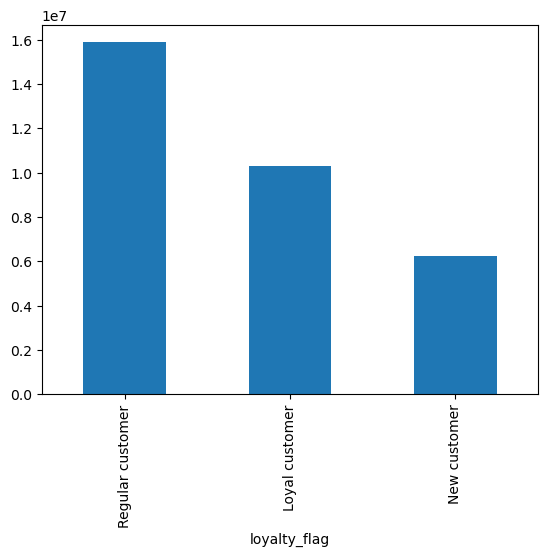

In [19]:
bar = ords_prods_merge_custs['loyalty_flag'].value_counts().plot.bar()

### Insights: If you remember from an earlier grouping exercise, a "Regular customer” is one whose median “days_since_prior_order” is higher than 10 and lower than or equal to 20 days. While a  “Loyal customer” has a a median lower than or equal to 10 and a “Non-frequent customer” has a median higher than 20. 

### The highest number of of orders are placed by "regular customers", who basically shop regulary at Instacart at intervals of roughly between 10 days to 20 days. Followed by "loyal customers", who shop with Instacart regularly within 10 days or less. This means, the Marketing team should focus their efforts on creating targeted ads appealing to the regular customers first, and then perhaps, if budget permits, also their loyal customers to increase sales and revenue. 

## Expenditure  

#### Sampling 

In [25]:
np.random.seed(4)

In [27]:
dev = np.random.rand(len(ords_prods_merge_custs)) <= 0.7

In [28]:
dev

array([False,  True, False, ...,  True,  True,  True], shape=(32404859,))

In [29]:
np.random.rand(10)

array([0.93546686, 0.06557465, 0.85698584, 0.24456371, 0.22683171,
       0.17068366, 0.27008946, 0.52534234, 0.83151571, 0.78153402])

In [31]:
big = ords_prods_merge_custs[dev]
small = ords_prods_merge_custs[~dev]

In [32]:
len(ords_prods_merge_custs)

32404859

In [33]:
len(big) + len(small)

32404859

### Lenghts match, which is a good sign and sampling with random numbers between 0 and 1 was successful 

In [34]:
df = small[['order_hour_of_day','prices']]

# 5. Line Plot for sales-related expenditure based on the hour of the day

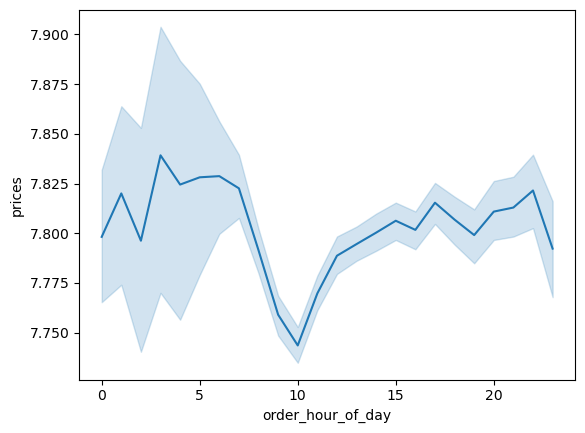

In [35]:
line = sns.lineplot(data = df, x = 'order_hour_of_day',y = 'prices')

#### Insights: Yes, there seems to be a dip in sales related expenditure around 10:00 AM.

# 6. Line Plot related to age and number of dependants

In [36]:
df_2 = small[['number_of_dependants','age']]

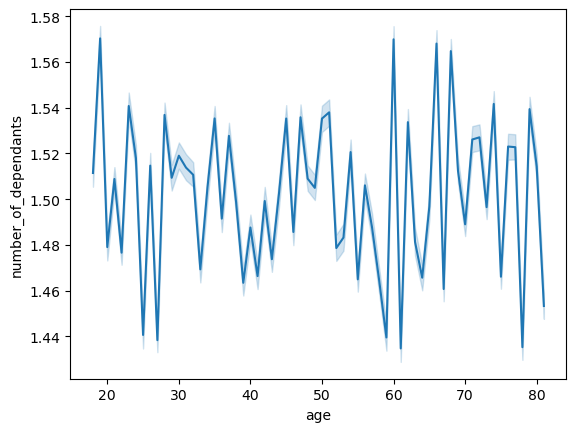

In [37]:
line_2 = sns.lineplot(data = df_2, x = 'age',y = 'number_of_dependants')

#### Insights: Across all age groups, the values stay close to about 1.5 dependants. This means customers shopping at InstaCart of different ages have between one and two dependants. The pattern remains fairly consistent with no surprising upward or downward trend nor unexpected outliers, suggesting that age doesn't have a strong relationship with the number of dependants in this dataset. 

# Scatter Plot representing relationship between income and age

In [38]:
df_3 = small[['income','age']]

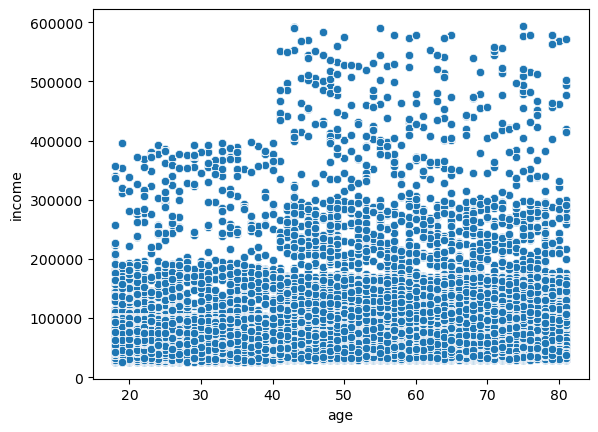

In [40]:
scatterplot = sns.scatterplot(x = 'age', y = 'income', data = df_3)

#### Insights: Points are widely scattered with no clear no surprising upward or downward trend nor unexpected outliers. This means that income is not strongly related to age in this dataset. However, the scatterplot does showcase how income varies greatly at different age. Age alone cannot predict higher or lower earnings in this sample. An observation to note here, is that many customers in their 40s and above that age, have a much higher income range, in comparison to someone in thier 20s or 30s. 

# Exporting Visualizations 

#### Exporting to the Vizualisations folder in png format

In [41]:
hist.figure.savefig(os.path.join(path, '04 Analysis','Vizualisations', 'hist_order_hour_of_day.png'))

In [42]:
bar.figure.savefig(os.path.join(path, '04 Analysis','Vizualisations', 'bar_loyalty_flag.png'))

In [43]:
line.figure.savefig(os.path.join(path, '04 Analysis','Vizualisations', 'line_expenditure_vs_hour_of_day.png'))

In [44]:
line_2.figure.savefig(os.path.join(path, '04 Analysis','Vizualisations', 'line_2_age_vs_number_of_dependants.png'))

In [45]:
scatterplot.figure.savefig(os.path.join(path, '04 Analysis','Vizualisations', 'scatter_age_vs_income.png'))

# Exporting Script

In [47]:
ords_prods_merge_custs.to_pickle(os.path.join(path, '02 Data','Prepared Data', 'ords_prods_merge_custs_viz.pkl'))